# Chunking Strategy Comparison

Quantitative comparison of three chunking strategies on the HF Transformers docs corpus:
- **Fixed-size**: Character-based splitting with overlap
- **Recursive**: Hierarchical splitting (paragraphs → lines → sentences → words)
- **Header-based**: Split on markdown headers, preserving document structure

We evaluate retrieval quality using **P@k**, **Recall@k**, **MRR**, and **nDCG** against a hand-curated evaluation set of queries with known relevant documents.

**Prerequisites**: Run these scripts first to build all three indices:
```bash
python scripts/fetch_docs.py
python scripts/build_index.py --strategy fixed
python scripts/build_index.py --strategy recursive
python scripts/build_index.py --strategy header
```

In [1]:
import pickle
import sys
from pathlib import Path

import faiss
import numpy as np

# Ensure the project root is on the path
project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(project_root / "src"))

from docsense.config import DATA_DIR, Settings
from docsense.embedding.embedder import Embedder
from docsense.evaluation.retrieval_metrics import (
    deduplicate_preserving_order,
    mean_reciprocal_rank,
    ndcg_at_k,
    precision_at_k,
    recall_at_k,
)

config = Settings()
INDEX_DIR = DATA_DIR / "index"
STRATEGIES = ["fixed", "recursive", "header"]

# Load all three indices
indices = {}
chunks = {}
for strategy in STRATEGIES:
    idx_dir = INDEX_DIR / strategy
    indices[strategy] = faiss.read_index(str(idx_dir / "index.faiss"))
    with open(idx_dir / "chunks.pkl", "rb") as f:
        chunks[strategy] = pickle.load(f)
    print(f"{strategy:>10}: {indices[strategy].ntotal:,} vectors, {len(chunks[strategy]):,} chunks")

# Shared embedder for queries
embedder = Embedder(config.embedding)
print(f"\nEmbedder loaded: {config.embedding.model_name}")

     fixed: 10,681 vectors, 10,681 chunks
 recursive: 12,601 vectors, 12,601 chunks
    header: 14,218 vectors, 14,218 chunks

Embedder loaded: sentence-transformers/all-MiniLM-L6-v2


## Evaluation Set

Hand-curated queries with known relevant source documents. Each query maps to 1-3 documents in the corpus that should be retrieved. Relevance is judged at the **document level** — a retrieved chunk is "relevant" if its `doc_id` matches any of the expected source files.

This is a pragmatic approach for comparing chunking strategies. A full evaluation would need human relevance judgments at the passage level.

In [2]:
# Curated eval queries are now maintained in the evaluation module so they
# can be reused across notebooks, scripts, and re-runs after the re-ranker
# lands. See the docstring in eval_queries.py for the selection-bias caveat.
from docsense.evaluation.eval_queries import CURATED_QUERIES as EVAL_SET

print(f"Evaluation set: {len(EVAL_SET)} queries (hand-curated — see eval_queries.py for bias notes)")

Evaluation set: 20 queries (hand-curated — see eval_queries.py for bias notes)


## Retrieval Evaluation

For each query, retrieve the top-k chunks from each index and check if they come from the expected source documents.

In [3]:
TOP_K = 10

def is_relevant(doc_id: str, relevant_prefixes: list[str]) -> bool:
    """Check if a chunk's doc_id matches any of the relevant document prefixes."""
    return any(doc_id.startswith(prefix) for prefix in relevant_prefixes)


def evaluate_strategy(strategy: str, top_k: int = TOP_K) -> list[dict]:
    """Run all eval queries against a strategy's index, return per-query results.

    Retrieval is at chunk granularity but relevance is judged at document
    granularity, so we deduplicate doc_ids preserving rank order before
    handing them to the metric functions. Without this, multiple chunks from
    the same relevant document each count as separate hits and recall/nDCG
    can exceed 1.0.
    """
    index = indices[strategy]
    chunk_list = chunks[strategy]
    results = []

    for query, relevant_prefixes in EVAL_SET:
        query_emb = embedder.embed_texts([query])
        # Over-retrieve so that after dedup we still have ~top_k unique docs
        k_chunks = min(top_k * 4, index.ntotal)
        scores, idxs = index.search(query_emb, k_chunks)

        # Collect retrieved doc_ids (in chunk-rank order), then dedupe to
        # produce a document-level ranking suitable for the metrics
        chunk_ranked_doc_ids = []
        for idx in idxs[0]:
            if idx == -1:
                break
            chunk_ranked_doc_ids.append(chunk_list[idx].doc_id)
        retrieved_doc_ids = deduplicate_preserving_order(chunk_ranked_doc_ids)

        # Build relevant_ids: every doc_id in the corpus matching any prefix
        all_relevant_ids = set()
        for c in chunk_list:
            if is_relevant(c.doc_id, relevant_prefixes):
                all_relevant_ids.add(c.doc_id)

        results.append({
            "query": query,
            "retrieved_doc_ids": retrieved_doc_ids,
            "relevant_ids": all_relevant_ids,
            "relevant_prefixes": relevant_prefixes,
        })

    return results


# Run evaluation for all strategies
all_results = {}
for strategy in STRATEGIES:
    print(f"Evaluating {strategy}...")
    all_results[strategy] = evaluate_strategy(strategy)
print("Done.")

Evaluating fixed...


/home/sethz/projects/docsense/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loading weights:   0%|          | 0/103 [00:00<?, ?it/s]

Loading weights: 100%|██████████| 103/103 [00:00<00:00, 1399.35it/s]


BertModel LOAD REPORT from: sentence-transformers/all-MiniLM-L6-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Evaluating recursive...


Evaluating header...


Done.


## Compute Metrics

In [4]:
K_VALUES = [1, 3, 5, 10]

def compute_metrics(results: list[dict]) -> dict:
    """Compute aggregate retrieval metrics across all queries."""
    metrics = {}

    for k in K_VALUES:
        p_scores = [precision_at_k(r["retrieved_doc_ids"], r["relevant_ids"], k) for r in results]
        r_scores = [recall_at_k(r["retrieved_doc_ids"], r["relevant_ids"], k) for r in results]
        ndcg_scores = [ndcg_at_k(r["retrieved_doc_ids"], r["relevant_ids"], k) for r in results]

        metrics[f"P@{k}"] = np.mean(p_scores)
        metrics[f"Recall@{k}"] = np.mean(r_scores)
        metrics[f"nDCG@{k}"] = np.mean(ndcg_scores)

    mrr_scores = [mean_reciprocal_rank(r["retrieved_doc_ids"], r["relevant_ids"]) for r in results]
    metrics["MRR"] = np.mean(mrr_scores)

    return metrics


# Compute metrics for all strategies
strategy_metrics = {}
for strategy in STRATEGIES:
    strategy_metrics[strategy] = compute_metrics(all_results[strategy])

# Display as table
print(f"{'Metric':<12}", end="")
for s in STRATEGIES:
    print(f"{s:>12}", end="")
print()
print("-" * 48)

for metric in ["MRR"] + [f"{m}@{k}" for k in K_VALUES for m in ["P", "Recall", "nDCG"]]:
    if metric not in strategy_metrics["fixed"]:
        continue
    print(f"{metric:<12}", end="")
    for s in STRATEGIES:
        print(f"{strategy_metrics[s][metric]:>12.3f}", end="")
    print()

Metric             fixed   recursive      header
------------------------------------------------
MRR                0.551       0.692       0.623
P@1                0.350       0.550       0.450
Recall@1           0.227       0.352       0.277
nDCG@1             0.350       0.550       0.450
P@3                0.283       0.317       0.350
Recall@3           0.530       0.604       0.630
nDCG@3             0.481       0.586       0.577
P@5                0.220       0.230       0.250
Recall@5           0.659       0.657       0.709
nDCG@5             0.535       0.615       0.610
P@10               0.140       0.155       0.155
Recall@10          0.764       0.863       0.743
nDCG@10            0.565       0.684       0.620


## Visualizations

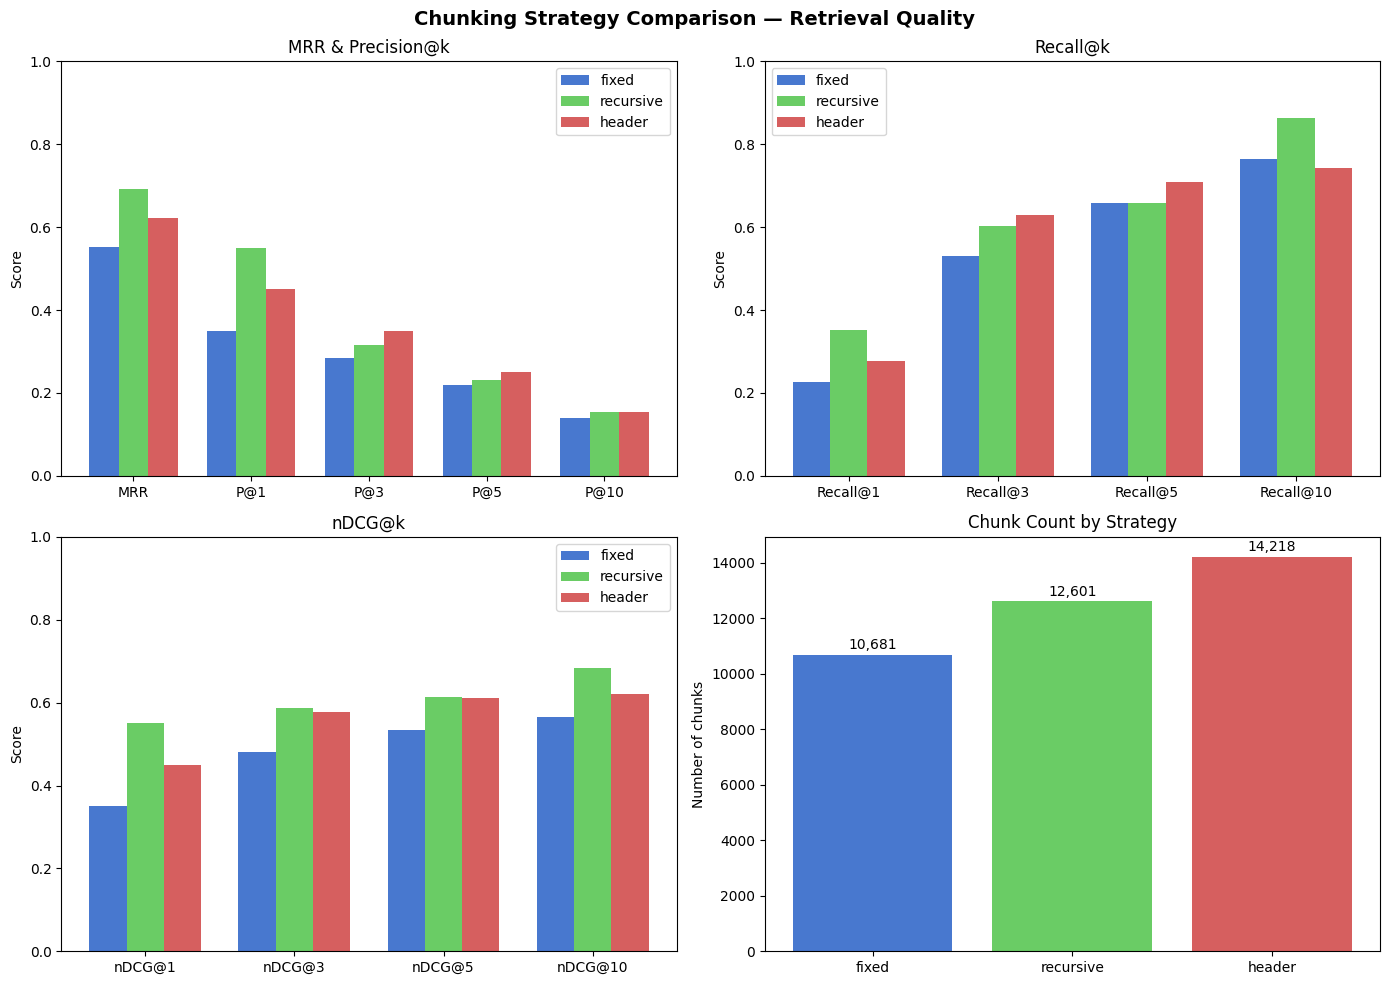

In [5]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle("Chunking Strategy Comparison — Retrieval Quality", fontsize=14, fontweight="bold")

colors = {"fixed": "#4878CF", "recursive": "#6ACC65", "header": "#D65F5F"}

# Plot 1: MRR + P@k
ax = axes[0, 0]
metrics_to_plot = ["MRR", "P@1", "P@3", "P@5", "P@10"]
x = np.arange(len(metrics_to_plot))
width = 0.25
for i, strategy in enumerate(STRATEGIES):
    values = [strategy_metrics[strategy][m] for m in metrics_to_plot]
    ax.bar(x + i * width, values, width, label=strategy, color=colors[strategy])
ax.set_ylabel("Score")
ax.set_title("MRR & Precision@k")
ax.set_xticks(x + width)
ax.set_xticklabels(metrics_to_plot)
ax.legend()
ax.set_ylim(0, 1)

# Plot 2: Recall@k
ax = axes[0, 1]
recall_metrics = [f"Recall@{k}" for k in K_VALUES]
x = np.arange(len(recall_metrics))
for i, strategy in enumerate(STRATEGIES):
    values = [strategy_metrics[strategy][m] for m in recall_metrics]
    ax.bar(x + i * width, values, width, label=strategy, color=colors[strategy])
ax.set_ylabel("Score")
ax.set_title("Recall@k")
ax.set_xticks(x + width)
ax.set_xticklabels(recall_metrics)
ax.legend()
ax.set_ylim(0, 1)

# Plot 3: nDCG@k
ax = axes[1, 0]
ndcg_metrics = [f"nDCG@{k}" for k in K_VALUES]
x = np.arange(len(ndcg_metrics))
for i, strategy in enumerate(STRATEGIES):
    values = [strategy_metrics[strategy][m] for m in ndcg_metrics]
    ax.bar(x + i * width, values, width, label=strategy, color=colors[strategy])
ax.set_ylabel("Score")
ax.set_title("nDCG@k")
ax.set_xticks(x + width)
ax.set_xticklabels(ndcg_metrics)
ax.legend()
ax.set_ylim(0, 1)

# Plot 4: Chunk count comparison
ax = axes[1, 1]
chunk_counts = [len(chunks[s]) for s in STRATEGIES]
bars = ax.bar(STRATEGIES, chunk_counts, color=[colors[s] for s in STRATEGIES])
ax.set_ylabel("Number of chunks")
ax.set_title("Chunk Count by Strategy")
for bar, count in zip(bars, chunk_counts, strict=True):
    ax.text(bar.get_x() + bar.get_width()/2., bar.get_height() + 100,
            f"{count:,}", ha="center", va="bottom", fontsize=10)

plt.tight_layout()
plt.savefig("chunking_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## Per-Query Breakdown

See which queries each strategy gets right and wrong. Useful for diagnosing where structure-aware chunking helps (or doesn't).

In [6]:
# Per-query hit rate at k=5: did the strategy find at least one relevant doc?
print(f"{'Query':<55} {'fixed':>7} {'recur':>7} {'header':>7}")
print("-" * 78)

for i, (query, _) in enumerate(EVAL_SET):
    short_q = query[:52] + "..." if len(query) > 55 else query
    hits = []
    for s in STRATEGIES:
        r = all_results[s][i]
        top5 = r["retrieved_doc_ids"][:5]
        hit = "Y" if any(doc_id in r["relevant_ids"] for doc_id in top5) else "-"
        hits.append(hit)
    print(f"{short_q:<55} {hits[0]:>7} {hits[1]:>7} {hits[2]:>7}")

# Summary: count of hits per strategy
print("-" * 78)
for s in STRATEGIES:
    hit_count = sum(
        1 for r in all_results[s]
        if any(doc_id in r["relevant_ids"] for doc_id in r["retrieved_doc_ids"][:5])
    )
    print(f"  {s}: {hit_count}/{len(EVAL_SET)} queries with a relevant hit in top 5")

Query                                                     fixed   recur  header
------------------------------------------------------------------------------
How do I install transformers?                                -       -       -
What are the different types of tokenizers?                   Y       Y       Y
How does the pipeline API work?                               Y       -       Y
What is gradient checkpointing and when should I use...       Y       Y       Y
How do I use AutoModel to load a pretrained model?            Y       Y       Y
How do I fine-tune a model with Trainer?                      -       Y       Y
How to train on multiple GPUs with data parallelism?          Y       Y       Y
What is DeepSpeed and how do I use it with transform...       Y       Y       Y
How do I customize the training loop with callbacks?          Y       Y       Y
How to do hyperparameter search?                              Y       Y       Y
How does text generation work in transfor

## Sample Retrieved Chunks

Inspect what each strategy actually retrieves for a few queries, to build intuition beyond the numbers.

In [7]:
# Pick a few interesting queries to inspect
INSPECT_QUERIES = [3, 5, 11]  # gradient checkpointing, fine-tune with Trainer, beam search

for qi in INSPECT_QUERIES:
    query, relevant_prefixes = EVAL_SET[qi]
    print(f"\n{'='*80}")
    print(f"Query: {query}")
    print(f"Expected: {relevant_prefixes}")
    print(f"{'='*80}")

    for strategy in STRATEGIES:
        r = all_results[strategy][qi]
        print(f"\n  [{strategy}]")
        for rank, doc_id in enumerate(r["retrieved_doc_ids"][:3], 1):
            marker = "HIT" if doc_id in r["relevant_ids"] else "   "
            print(f"    {rank}. [{marker}] {doc_id}")


Query: What is gradient checkpointing and when should I use it?
Expected: ['perf_train_gpu_one.md', 'deepspeed.md']

  [fixed]
    1. [   ] training.md
    2. [HIT] deepspeed.md
    3. [   ] model_doc/beit.md

  [recursive]
    1. [HIT] perf_train_gpu_one.md
    2. [HIT] deepspeed.md
    3. [   ] training.md

  [header]
    1. [HIT] deepspeed.md
    2. [HIT] perf_train_gpu_one.md
    3. [   ] training.md

Query: How do I fine-tune a model with Trainer?
Expected: ['trainer.md', 'training.md']

  [fixed]
    1. [   ] trainer_callbacks.md
    2. [   ] tasks/image_classification.md
    3. [   ] tasks/audio_classification.md

  [recursive]
    1. [HIT] training.md
    2. [   ] tasks/sequence_classification.md
    3. [   ] tasks/audio_classification.md

  [header]
    1. [   ] model_doc/xmod.md
    2. [   ] tasks/audio_classification.md
    3. [HIT] training.md

Query: What are the different decoding strategies like beam search?
Expected: ['generation_strategies.md']

  [fixed]
    1. [HIT]

## Conclusions

**Recursive chunking wins on ranking quality** — the gap is smaller than the
first run suggested, but the order is unchanged:

| | Fixed | Recursive | Header |
|---|---|---|---|
| **MRR** | 0.551 | **0.692** | 0.623 |
| **P@1** | 0.350 | **0.550** | 0.450 |
| **Recall@10** | 0.764 | **0.863** | 0.743 |
| **nDCG@10** | 0.565 | **0.684** | 0.620 |
| **Hit rate (top 5)** | 16/20 | 16/20 | **17/20** |

Recursive is best on the rank-sensitive metrics (MRR, P@1, nDCG, Recall@10),
which are the ones that matter most when the downstream LLM only sees the
top few chunks. Header edges out on hit-rate@5 — one extra query lands a
relevant doc in the top 5 — but loses on *where* in the top 5 those hits
appear. For a system that's about to feed the top-k into a context window,
ranking quality matters more than presence-or-absence.

### Why recursive wins

The original hypothesis was that header-based chunking would dominate by
preserving section structure. It didn't, because:

1. **Header chunks are larger** (14,218 chunks vs 12,601 recursive). The
   single 384-d MiniLM vector has to compress more content, so the
   embedding represents the section as a whole rather than the specific
   subtopic the query is about.
2. **Recursive splits at natural boundaries within sections** — a chunk
   about "gradient checkpointing" is *just* about gradient checkpointing,
   not also about mixed-precision training that happened to be in the
   same `## Memory optimization` section.
3. **Fixed-size performs worst** as expected — cutting mid-paragraph
   damages semantic coherence.

In short: with a small bi-encoder, *specificity* beats *structure*.

### Header is more competitive than expected

The corrected numbers tell a less one-sided story than the first run
suggested. Header was originally reported with inflated recall/nDCG
because the eval was double-counting chunks from the same relevant doc
(see the metrics-bug fix in commit `446662a`). Once corrected, header
beats fixed on every metric and is within a few points of recursive on
hit-rate. This shifts the prior heading into Phase 2: the cross-encoder
re-ranker can score longer chunks more carefully than a bi-encoder, and
header chunks are exactly the case where re-ranking should help most.
A re-bakeoff after the re-ranker lands is genuinely worth running —
header is closer than the original numbers implied, and might overtake
recursive once length stops being a handicap.

### Eval methodology notes

- **Retrieval is at chunk granularity, relevance is at document
  granularity.** Multiple chunks from the same relevant doc each count
  as one — we deduplicate doc_ids preserving rank order before computing
  metrics. (See `deduplicate_preserving_order` in
  `evaluation/retrieval_metrics.py`.)
- **Selection bias.** The 20 queries were hand-curated and reward
  retrieval that mirrors the curator's mental model. A complementary,
  unbiased eval set generated programmatically from document headings
  is being scaffolded (`evaluation/structural_queries.py`) for the
  re-bakeoff.

### Next steps

- **Use recursive as the default chunking strategy.** Confirmed by data,
  not just intuition.
- **Re-run this bakeoff after the cross-encoder re-ranker is in place.**
  Header is the strategy most likely to benefit from re-ranking, and the
  current numbers are tight enough that the ordering could change.
- **Run the structural eval set alongside the curated one** on the
  re-bakeoff. Agreement strengthens the conclusion; disagreement is its
  own signal worth investigating.